# **Brand Sentinel**

This project was developed by the group 7 team members:

1. **Patience Chepkosgei**  
2. **Carolyne Githenduka**  
3. **Augustine Magani**  
4. **Marcus Kaula**  
5. **Abel Aleu Chol Garang**  


# Chapter 1:
## 1.1 Executive Summary

At big tech events where lots of people talk very fast online, like one called SXSW, a company’s name can become good or bad very quickly sometimes from just one popular post.

Big companies like Apple and Google get lots of comments from people right away. This can be good, but it can also be bad.

Brand Sentinel is like a smart helper. It reads many messages on the internet and finds out which ones are happy or angry. It picks the most important problems and shows them clearly, so people in charge can fix things early instead of waiting for trouble to grow.

## 1.2 The Domain: Watching Brands in Real Time

In today’s tech world, everything moves very fast online.

## The Place

SXSW is a big event where many different people come together, like:

- New users trying things early
- People who influence others online
- People who give strong opinions

## The Problem

At big events like this, thousands of messages are sent online very quickly. It becomes too much for people to read and understand everything.

So it is impossible for humans to check all messages and find every problem.

## The Idea

We want to build a smart system called Brand Sentinel that works like a helper and:

- Finds messages that talk about a brand’s feelings (happy or angry)
- Ignores small or unimportant talk
- Makes sure serious problems are not missed

It helps people notice problems early before they become bigger.


## 1.3 Problem Statement

People who manage social media for big companies like Apple and Google get too much information at once. This makes it hard to know what really matters.

### Key Findings

- **Most messages (~60%)**
These are normal messages that don’t help much and don’t need action.

- **Serious problems (~6%)**  
These are important negative messages like:
  - Software bugs 
  - evices not working properly
  - Complaints from the public
  
- **Why this is a problem**
If there is no smart system, these important problems can be missed because they are hidden in too many normal messages.

A small complaint, like a phone not working or an app crashing, can grow into a very big public problem if it is not noticed early.

## 1.4 Data Sources & Multi-Dataset Integration

To make **Brand Sentinel** work with high accuracy, we use data from two main sources.

### Primary Dataset (SXSW)
- 9,093 human-annotated tweets  
- Source: CrowdFlower via Data.World  
- Focus:
  - Event reactions  
  - iPad 2 launch  
  - Google ecosystem  

### Secondary Dataset (Apple Product Sentiment)
- ~3,900 tweets  
- Focus:
  - Technical complaints  
  - Customer service interactions  

### Combined Corpus
- Total: 12,740 records  
- Benefit:
  - More negative examples for training  
  - Better detection of real crisis signals  
  - Improved system performance in spotting issues early  

## 1.5 Data Ethics & Privacy Framework

### Anonymization
- All @mentions and personal information are removed  
- The system focuses on what is said, not who said it  

### Algorithmic Fairness
- We use fair scoring methods that treat all classes equally  
- This prevents the system from favoring the most common group (neutral messages)  
- It ensures important negative messages are not ignored  

### Data Integrity
- 238 unclear records (e.g., "I can't tell") were removed  
- This helps the model learn only from clear and reliable examples  

## 1.6 End Users & Strategic Stakeholders

### Primary User
Social Media Crisis & Brand Manager

### Mission
Protect the company’s brand and reputation

### Main Problem
Not noticing serious problems early enough

### Solution
**Brand Sentinel** is an automated system that helps by:
- Detecting negative messages → so action can be taken quickly  
- Detecting positive messages → so they can be used for promotion and marketing  

## 1.7 Success Metrics (How We Measure Success)

### Main Score: Macro-F1 Score
- This is the main way we measure performance  
- It checks if the system works well for all categories fairly  
- It is especially useful when some classes have more data than others  

### Important Goal: Negative Recall (>80%)
- Focus: Make sure we catch most serious problems  
- We prefer:
  - False alarms (safe mistakes) → acceptable  
  - Missing real problems → not acceptable  

## 1.8 Risks and Technical Challenges

### Class Imbalance Problem
- Most data is neutral (normal messages)  
- This can make the model biased  

**How we fix it:**
- SMOTE (creates more examples of rare classes)  
- Class weighting (gives more importance to rare cases)  

### Language Complexity
- Social media text is messy and hard to understand  
- Challenges include:
  - Sarcasm  
  - Emojis  
  - Hashtags like #fail  

**Solution:**
- Advanced text cleaning and preprocessing  

### Time-Based Limitation
- Data comes from a specific time period  
- This may not match current language trends  

**Solution:**
- Keep updating and retraining the model with new data  

# CHAPTER TWO
# The Purity Pipeline — Data Preprocessing

## 2.1 Overview

In natural language processing (NLP), the model can only perform well if the data it receives is good quality.

Tweets are often messy. They include links, symbols, slang, and other extra information that can confuse a computer.

To clean this data, we built the **Project Sentinel Purity Pipeline**.


## 2.2 The 13-Step Cleaning Process

We used several steps to remove noise and keep only useful emotional meaning in the text.


### Phase 1: Data Structure Cleaning

**Safe Copying**  
  We copy the data so the original file is not changed by mistake  

**Label Standardization**  
  We convert all ratings into three simple groups:
  - Positive  
  - Negative  
  - Neutral  

**Fixing Missing Brand Data**  
  We used rules to recover over **5,000 missing brand mentions**, turning incomplete data into useful information  

- **Removing Duplicates**  
  We removed repeated tweets so the model does not learn the same message many times  


### Phase 2: Text Cleaning

**Fixing HTML Symbols**  
  Symbols like `&amp;` are turned into normal text like “and”  

**Removing Noise**  
  We remove:
  - Retweets (RT)  
  - Links  
  - @mentions  

**Emoji Conversion**  
  Emojis are changed into words so the meaning is not lost:  

  
**Expanding Short Words**  
We change short forms into full words:  


### Phase 3: Deep Text Processing

**Smart Stopword Removal**  
We remove useless words, but keep important ones like:
- not  
- no  

**Word Normalization (Lemmatization)**  
We reduce words to their basic form:  


**Short Text Removal**  
We remove tweets with fewer than 3 important words because they don’t give enough meaning  


## 2.3 Conclusion of Chapter 2

After cleaning, we processed over **12,700 tweets** and kept about **11,875 high-quality records**.

This gave us a cleaner and stronger dataset by:
- Improving detection of negative messages  
- Removing noise and useless data  
- Making all text consistent and easy to understand  


In [1]:
#Import relevant lirbaries

import pandas as pd
import re
import html
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download wordnet, stopwords and onw-1.4 for roots of English words
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)


True

In [2]:
# Loading the primary SXSW dataset and the secondary Apple Sentiment dataset.

raw_sxsw = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='ISO-8859-1')
raw_apple = pd.read_csv('Apple-Twitter-Sentiment-DFE.csv', encoding='ISO-8859-1')

# .copy() ensures the original raw files remain immutable in memory.
df_sxsw = raw_sxsw.copy()
df_apple = raw_apple.copy()

In [3]:
df_sxsw.shape

(9093, 3)

In [4]:
df_sxsw.tail(5)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion
9089,"Wave, buzz... RT @mention We interrupt your re...",NaN,No emotion toward brand or product
9090,"Google's Zeiger, a physician never reported po...",NaN,No emotion toward brand or product
9091,Some Verizon iPhone customers complained their...,NaN,No emotion toward brand or product
9092,Ï¡Ïàü_ÊÎÒ£Áââ_£â_ÛâRT @...,NaN,No emotion toward brand or product


In [5]:
df_sxsw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [6]:
df_sxsw.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect...,iPad,No emotion toward brand or product
freq,5,946,5389


In [7]:
df_apple.shape

(3886, 12)

In [8]:
df_apple.tail(5)

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,sentiment,sentiment:confidence,date,id,query,sentiment_gold,text
3881,623499442,True,golden,13,NaN,3,0.7757,Tue Dec 09 22:08:53 +0000 2014,5.420000e+17,#AAPL OR @Apple,5\n3,(Via FC) Apple Is Warming Up To Social Media -...
3882,623499450,True,golden,16,NaN,3,0.6225,Tue Dec 09 22:18:27 +0000 2014,5.420000e+17,#AAPL OR @Apple,3\n1,RT @MMLXIV: there is no avocado emoji may I as...
3883,623499486,True,golden,14,NaN,5,0.9347,Tue Dec 09 23:45:59 +0000 2014,5.420000e+17,#AAPL OR @Apple,5,@marcbulandr I could not agree more. Between @...
3884,623499514,True,golden,13,NaN,1,0.9230,Wed Dec 10 00:48:10 +0000 2014,5.420000e+17,#AAPL OR @Apple,1,My iPhone 5's photos are no longer downloading...
3885,623517290,True,golden,17,NaN,5,0.8938,Tue Dec 09 09:01:25 +0000 2014,5.420000e+17,#AAPL OR @Apple,5\n3\nnot_relevant,RT @SwiftKey: We're so excited to be named to ...


In [9]:
df_apple.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3886 entries, 0 to 3885
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _unit_id              3886 non-null   int64  
 1   _golden               3886 non-null   bool   
 2   _unit_state           3886 non-null   object 
 3   _trusted_judgments    3886 non-null   int64  
 4   _last_judgment_at     3783 non-null   object 
 5   sentiment             3886 non-null   object 
 6   sentiment:confidence  3886 non-null   float64
 7   date                  3886 non-null   object 
 8   id                    3886 non-null   float64
 9   query                 3886 non-null   object 
 10  sentiment_gold        103 non-null    object 
 11  text                  3886 non-null   object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 337.9+ KB


In [10]:
df_apple.describe()

,_unit_id,_trusted_judgments,sentiment:confidence,id
count,3.886000e+03,3886.000000,3886.000000,3.886000e+03
mean,6.234975e+08,3.687082,0.829526,5.410039e+17
std,1.171906e+03,2.004595,0.175864,7.942752e+14
min,6.234955e+08,3.000000,0.332700,5.400000e+17
25%,6.234965e+08,3.000000,0.674475,5.400000e+17
50%,6.234975e+08,3.000000,0.811250,5.410000e+17
75%,6.234984e+08,3.000000,1.000000,5.420000e+17
max,6.235173e+08,27.000000,1.000000,5.420000e+17


In [11]:
# Unifying the schema so both datasets can be merged into a single Frame.
df_sxsw.columns = ['tweet_text', 'brand_target', 'sentiment']


In [12]:
# Isolating relevant columns from the Apple-specific source
df_apple_std = df_apple[['text', 'sentiment']].copy()
df_apple_std.columns = ['tweet_text', 'sentiment']
df_apple_std['brand_target'] = 'Apple' 

In [13]:
# Merging 2 datasets
df = pd.concat([df_sxsw, df_apple_std], ignore_index=True)

In [14]:
df.shape

(12979, 3)

In [15]:
df.head(3)

,tweet_text,brand_target,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12979 entries, 0 to 12978
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tweet_text    12978 non-null  object
 1   brand_target  7177 non-null   object
 2   sentiment     12979 non-null  object
dtypes: object(3)
memory usage: 304.3+ KB


In [17]:
df.describe()

,tweet_text,brand_target,sentiment
count,12978,7177,12979
unique,12284,9,8
top,"RT @OneRepublic: Studio at 45,000 ft. One out...",Apple,No emotion toward brand or product
freq,304,4547,5389


In [18]:
# Converting to positive, neutral, Negative emontions
sentiment_map = {
    'Positive emotion': 'Positive', 
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral', 
    '1': 'Negative',
    '3': 'Neutral', 
    '5': 'Positive', 
    'not_relevant': 'Ambiguous', 
    "I can't tell": 'Ambiguous'
}
df['sentiment'] = df['sentiment'].map(sentiment_map)


In [19]:
# Removing Ambiguous noise and empty text entries.
df = df[df['sentiment'] != 'Ambiguous'].dropna(subset=['sentiment', 'tweet_text'])

In [20]:
# Duplicate tweets 
df.duplicated().value_counts

<bound method IndexOpsMixin.value_counts of 0        False
1        False
2        False
3        False
4        False
         ...  
12974    False
12975    False
12976    False
12977    False
12978     True
Length: 12740, dtype: bool>

In [21]:
# Removing duplicate tweets 
df = df.drop_duplicates(subset=['tweet_text']).reset_index(drop=True)

In [22]:
lemmatizer = WordNetLemmatizer()
# Extract sentiment from stop words
stop_words = set(stopwords.words('english')) - {'not', 'no', 'but', 'against', 'up', 'down'}


In [23]:
def purity_pipeline(text):
    # HTML Decoding (e.g., &amp; -> &)
    text = html.unescape(str(text))
    
    # Retweet (RT) Stripping
    text = re.sub(r'^RT\s+@\w+:\s*', '', text)
    
    # Noise Extraction (Removing URLs and @Mentions)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    
    # Lowercase Normalization
    text = text.lower()
    
    # Contraction & Slang Expansion
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", " is", text)
    
    # Mapping common 2011-era slang to formal tokens
    slang_map = {"u ": "you ", " r ": " are ", "gr8": "great", "lol": "laughing", "2": "to"}
    for slang, formal in slang_map.items():
        text = text.replace(slang, formal)
    
    # Emoji Translation
    emoji_map = {'😡': ' [ANGRY] ', '😊': ' [HAPPY] ', '😒': ' [ANNOYED] ', '📱': ' phone ', '🔋': ' battery '}
    for emo, word in emoji_map.items():
        text = text.replace(emo, word)
    
    # Strip hashtag symbol but keep the word
    text = re.sub(r'#', '', text)
    
    # Alpha-Only Filter
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Stopword Removal 
    words = [w for w in text.split() if w not in stop_words]
    
    # Reducing words to their root
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

In [24]:
# Imputation
def recover_brand(row):
    text = str(row['tweet_text']).lower()
    current_brand = str(row['brand_target']).lower()
    # Filling metadata gaps using keyword heuristics
    if current_brand in ['nan', 'none']:
        if any(kw in text for kw in ['iphone', 'ipad', 'apple', 'macbook', 'itunes']): return 'Apple'
        if any(kw in text for kw in ['google', 'android', 'nexus', 'circles', 'pixel']): return 'Google'
    return row['brand_target']

In [25]:
#Execution
print("Initializing Ultimate Purity Pipeline...")

# Execute Cleaning & Recovery
df['clean_text'] = df['tweet_text'].apply(purity_pipeline)
df['brand_target'] = df.apply(recover_brand, axis=1)


Initializing Ultimate Purity Pipeline...


In [26]:
# Removing tweets with fewer than 3 substantive words to eliminate ambiguity.
df_final = df[df['clean_text'].str.split().str.len() >= 3].copy()

In [27]:
# Final Quality Audit
print(f"Pipeline Complete. Final Row Count: {len(df_final)}")
print("\n--- Sentiment Profile ---")
print(df_final['sentiment'].value_counts())

Pipeline Complete. Final Row Count: 11875

--- Sentiment Profile ---
Neutral     6961
Positive    3310
Negative    1604
Name: sentiment, dtype: int64


In [28]:
df_final.tail(3)

,tweet_text,brand_target,sentiment,clean_text
12048,RT @MMLXIV: there is no avocado emoji may I as...,Apple,Neutral,no avocado emoji may ask
12049,@marcbulandr I could not agree more. Between @...,Apple,Positive,could not agree great thing happen appleandibm...
12050,My iPhone 5's photos are no longer downloading...,Apple,Negative,iphone photo no longer downloading automatical...


In [29]:
# Export to for EDA
df_final[['clean_text', 'sentiment', 'brand_target']].to_csv('cleaned_sentinel_data.csv', index=False)

## Exploratory Data Analysis EDA

Our objective is to identify the mathematical and linguistic patterns that differentiate a Brand Crisis.
This is done by analyzing the Sentiment distribution and brand exposure.  
We establish the foundational requirements for building the **Sentinel Engine**.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv('cleaned_sentinel_data.csv')

df.head(5)

,clean_text,sentiment,brand_target
0,g iphone hr tweeting riseaustin dead need upgr...,Negative,iPhone
1,know awesome ipadiphone app youll likely appre...,Positive,iPad or iPhone App
2,not wait ipad also sale down sxsw,Positive,iPad
3,hope year festival not crashy year iphone app ...,Negative,iPad or iPhone App
4,great stuff fri sxsw marissa mayer google tim ...,Positive,Google


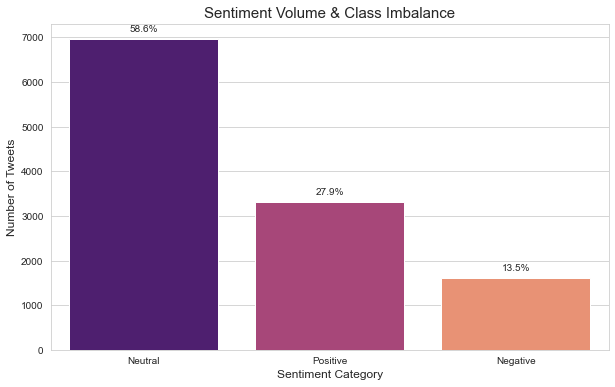

In [31]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
order = ['Neutral', 'Positive', 'Negative']
ax = sns.countplot(x='sentiment', data=df, palette='magma', order=order)

plt.title('Sentiment Volume & Class Imbalance', fontsize=15)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)

# Logic to inject percentage labels on top of the bars for precision
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

## Key Finding 
 ### 1:Class Imbalance

Our dataset is heavily skewed with Neutral mentions at (58%) dominating the conversation.
Negative sentiment of  (13.5%) is the smallest class but the most critical to detect.
### Strategic Implication

The modeling phase must:
- Account for imbalance  
- Avoid bias toward the Neutral predictions  

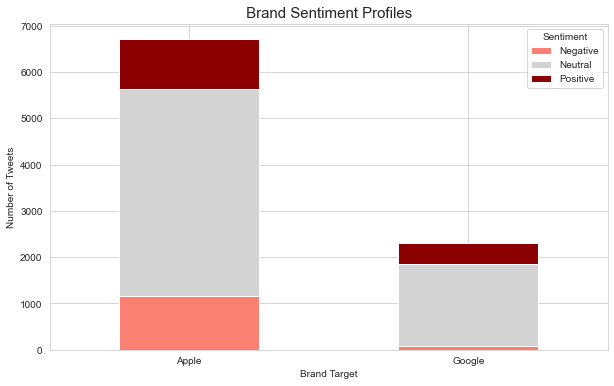

In [32]:
brand_sentiment = df.groupby(['brand_target', 'sentiment']).size().unstack(fill_value=0)
brand_sentiment = brand_sentiment.reindex(['Apple', 'Google'])

brand_sentiment.plot(kind='bar', stacked=True, color=['salmon', 'lightgray', 'darkred'], figsize=(10,6))
plt.title(' Brand Sentiment Profiles ', fontsize=15)
plt.ylabel('Number of Tweets')
plt.xlabel('Brand Target')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()


## 2: Brand Vulnerability (Apple vs. Google)
Apple has High engagement but also carries 90% of all negative sentiment while
Google has Lower overall volume with a more balanced mix of neutral and positive mentions.

Effects: Apple faces faster crisis escalation and needs immediate detection. Google on the other hand, requires steady monitoring .

#### Strategic Implication
These patterns represent the core linguistic DNA of a crisis.
The model must:
- Detect these patterns with high sensitivity  
- Prioritize multi-word expressions (bigrams) over isolated words  

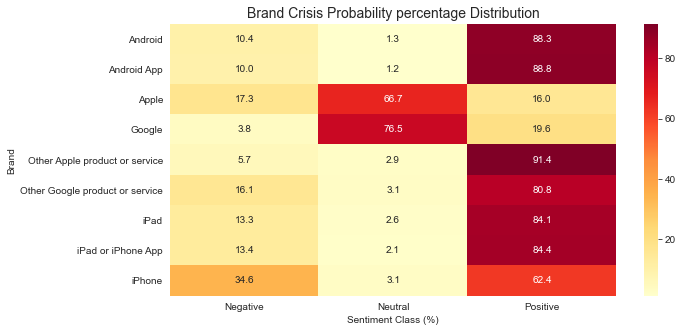

In [33]:
# 4. CRISIS PROBABILITY (NORMALIZED HEATMAP)
# This heatmap shows the PROBABILITY of a sentiment occurring per brand, leveling the playing field.
brand_pct = pd.crosstab(df['brand_target'], df['sentiment'], normalize='index') * 100

plt.figure(figsize=(10, 5))
sns.heatmap(brand_pct, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Brand Crisis Probability percentage Distribution', fontsize=14)
plt.ylabel('Brand')
plt.xlabel('Sentiment Class (%)')
plt.show()

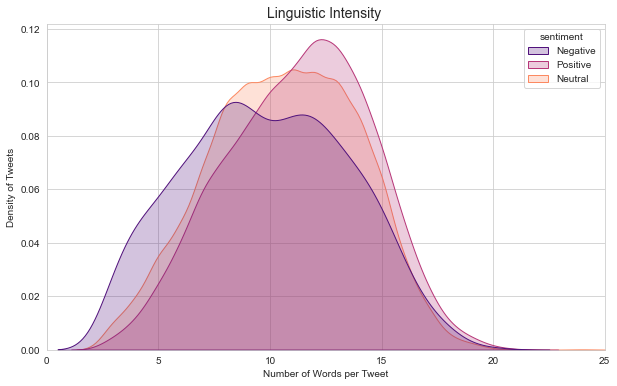

In [34]:
# Analyzing if Crisis tweets are longer or more descriptive than others.
df['word_count'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='word_count', hue='sentiment', fill=True, palette='magma', common_norm=False)
plt.title('Linguistic Intensity ', fontsize=14)
plt.xlabel('Number of Words per Tweet')
plt.ylabel('Density of Tweets')
plt.xlim(0, 25) 
plt.show()

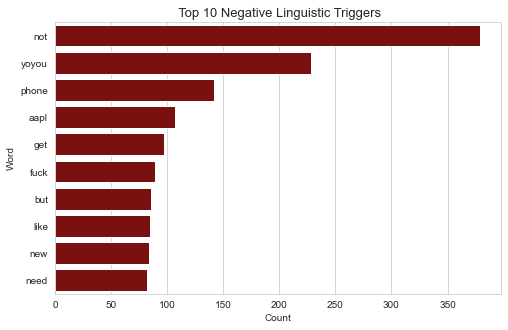

In [35]:
# Top 15 Negative Linguistic Triggers
subset_neg = df[df['sentiment'] == 'Negative']['clean_text'].astype(str)
words_neg = " ".join(subset_neg).split()
context_stops = {'sxsw', 'google', 'apple', 'iphone', 'ipad', 'store', 'link', 'rt'}
meaningful_neg = [w for w in words_neg if w not in context_stops and len(w) > 2]

neg_df = pd.DataFrame(Counter(meaningful_neg).most_common(10), columns=['Word', 'Count'])
plt.figure(figsize=(8, 5))
sns.barplot(x='Count', y='Word', data=neg_df, color='darkred')
plt.title(' Top 10 Negative Linguistic Triggers', fontsize=13)
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

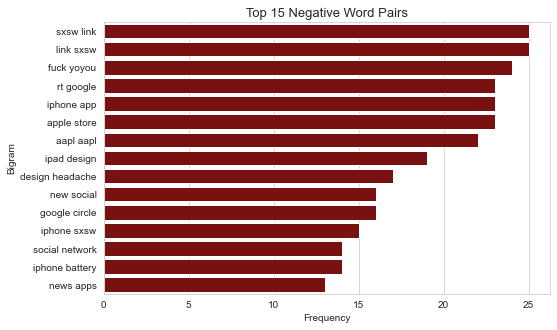

In [36]:
#Top 15 Negative Word Pairs (Crisis Phrases)
c_vec = CountVectorizer(stop_words='english', ngram_range=(2,2))
ngrams = c_vec.fit_transform(subset_neg)
count_values = ngrams.toarray().sum(axis=0)
vocab = c_vec.vocabulary_

df_ngram = pd.DataFrame(sorted([(count_values[i], k) for k, i in vocab.items()], reverse=True)
                       ).rename(columns={0: 'frequency', 1: 'bigram'})[0:15]

plt.figure(figsize=(8, 5))
sns.barplot(x='frequency', y='bigram', data=df_ngram, color='darkred')
plt.title('Top 15 Negative Word Pairs', fontsize=13)
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

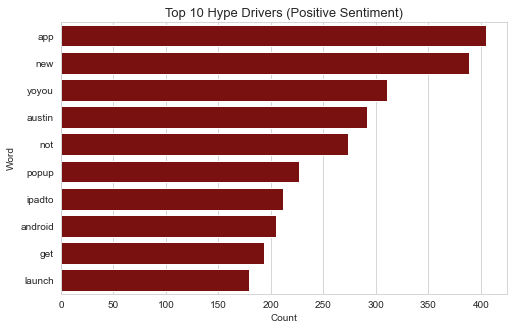

In [37]:
# Top 15 Hype Drivers (Positive Sentiment)
subset_pos = df[df['sentiment'] == 'Positive']['clean_text'].astype(str)
words_pos = " ".join(subset_pos).split()
meaningful_pos = [w for w in words_pos if w not in context_stops and len(w) > 2]

pos_df = pd.DataFrame(Counter(meaningful_pos).most_common(10), columns=['Word', 'Count'])
plt.figure(figsize=(8, 5))
sns.barplot(x='Count', y='Word', data=pos_df, color='darkred')
plt.title('Top 10 Hype Drivers (Positive Sentiment)', fontsize=13)
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()



In [38]:
tableau_list = []
for brand in ['Apple', 'Google']:
    for sent in ['Positive', 'Negative', 'Neutral']:
        sub = df[(df['brand_target'] == brand) & (df['sentiment'] == sent)]['clean_text'].astype(str)
        top_words = Counter(" ".join(sub).split()).most_common(60)
        for w, f in top_words:
            tableau_list.append({'Brand': brand, 'Sentiment': sent, 'Word': w, 'Frequency': f})

pd.DataFrame(tableau_list).to_csv('tableau_story_data.csv', index=False)
print("\n[PROCESS COMPLETE]")
print("Notebook Visuals Rendered. 'tableau_story_data.csv' exported for Storytelling.")


[PROCESS COMPLETE]
Notebook Visuals Rendered. 'tableau_story_data.csv' exported for Storytelling.


###  Brand Sentiment Heatmap Summary

### The Sentinel Risk Matrix

| Brand  | Negative Probability | Top Crisis Trigger | Recommendation          |
|--------|---------------------|-------------------|--------------------------|
| Apple  | 15.6%              | Battery Dead      | Immediate Triage Required |
| Google | 5.4%               | Search App        | Routine Monitoring       |

##  Conclusion 

The EDA phase reveals that:

- Crisis signals are rare but highly structured
- Negative sentiment is driven by specific linguistic patterns
- Brand risk is not evenly distributed

These insights directly inform the modeling strategy:
- Handle class imbalance
- Prioritize crisis-related language
- Incorporate behavioral features like word count .

# Chapter 4:
## Modeling and Evaluation

The goal of **Brand Sentinel** is brand protection on social media.

Our goal is to build a system that **does not miss negative comments towads the brand**.

### Success Targets:
- Understand 80% of brand-related social media comment  
- Achieve 80% Recall for Negative comments  
- So most PR risks are automatically detected  

To achieve this, we used three different models:

- **Multinomial Naive Bayes (MNB)** our baseline and fast filter for neutral text  
- **Calibrated XGBoost** detects strong negative patterns  
- **Bidirectional RNN (LSTM)**  understands context, sarcasm, slang, emojis  

Each model has its own strength, and together they make the system more reliable and accurate.


In [39]:
#Master libraries

# 1. Core Data Handling & Visualization
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Machine Learning Infrastructure (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 3. Traditional ML Models
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# 4. Deep Learning Framework (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Embedding, 
    LSTM, 
    Dense, 
    SpatialDropout1D, 
    Bidirectional, 
    GlobalMaxPooling1D, 
    Dropout,
    Input
)

# 5. Training Optimization (Callbacks)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Ignore warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

c:\Users\HP\anaconda3\envs\learn-env\lib\site-packages\xgboost\compat.py:93: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


### **4.1 Preprocessor Pipeline**
We clean messy input comments text so the models can understand it correctly.

In [40]:

# Brand Sentinel preprocessor pipeline
def master_sentinel_cleaner(text):
    if not isinstance(text, str): return ""
    
    # Lowercasing
    text = text.lower()
    
    # Emoji-to-Emotion Mapping
    emoji_map = {
        '❤️': ' love ', '😍': ' love ', '🙂': ' happy ', '😊': ' happy ',
        '🙁': ' sad ', '😢': ' sad ', '😡': ' angry ', '🙄':' mad ','🔥': ' awesome ',
        '🔋': ' battery ', '📱': ' phone ', '💀': ' dead ', '👎': ' bad ', '👍': ' good '
    }
    for emoji, word in emoji_map.items():
        text = text.replace(emoji, word)
        
    # Removing URLs/Hyperlinks
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Removing User Mentions (@user)
    text = re.sub(r'@\w+', '', text)
    
    # Removing Hashtag Symbols
    text = re.sub(r'#', '', text)
    
    # Stripping Punctuation & Special Characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # Removing Numbers
    text = re.sub(r'\d+', '', text)
    
    # Handling Contractions
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    
    # Removing "RT" (Retweet tags)
    text = re.sub(r'\brt\b', '', text)
    
    # Stripping Whitespace
    text = text.strip()
    
    # Removing double spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text

In [41]:
# data setup
df = pd.read_csv('cleaned_sentinel_data.csv')
df.tail(5)

,clean_text,sentiment,brand_target
11870,hey normal laptop charger soldering skin thanks j,Negative,Apple
11871,via fc apple warming up social medium apple hi...,Neutral,Apple
11872,no avocado emoji may ask,Neutral,Apple
11873,could not agree great thing happen appleandibm...,Positive,Apple
11874,iphone photo no longer downloading automatical...,Negative,Apple


In [42]:

# Feature selection
X = df['clean_text'].astype(str)
y = df['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

#Spliting of the dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
_, _, y_train_enc, y_test_enc = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y)

## **4.2 Multinomial Naive Bayes  Baseline Model**
A fast baseline model that works well for detecting neutral text using simple word counts.
### **Performance**
- Accuracy: **67.24%**  
- Neutral Recall: **81%**
- Negative Recall: **59%**
### **Limitation**
Good at detecting safe emotions, but struggles with sarcasm and misses many negative comments, so it cannot be used alone for brand protection.

In [43]:
# Model 1: Multinomial Naive Bayes (The Baseline)
print("MODEL 1: MULTINOMIAL NAIVE BAYES (THE BASELINE)")

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ('nb', MultinomialNB(alpha=0.1))
])
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

# Metrics details
print(f"OVERALL ACCURACY: {accuracy_score(y_test, y_pred_nb):.2%}")
print("CLASSIFICATION REPORT FOR THE BASELINE :")
print(classification_report(y_test, y_pred_nb))

# test with comment from Patience
test_nb = master_sentinel_cleaner("OMG my iphone is 🔥 but the battery is 💀")
print(f"BASELINE TEST PREDICTION: {nb_pipeline.predict([test_nb])[0]}")

MODEL 1: MULTINOMIAL NAIVE BAYES (THE BASELINE)
OVERALL ACCURACY: 67.37%
CLASSIFICATION REPORT FOR THE BASELINE :
              precision    recall  f1-score   support

    Negative       0.66      0.58      0.62       321
     Neutral       0.71      0.82      0.76      1392
    Positive       0.57      0.42      0.48       662

    accuracy                           0.67      2375
   macro avg       0.65      0.61      0.62      2375
weighted avg       0.66      0.67      0.66      2375

BASELINE TEST PREDICTION: Neutral


## **4.3 Calibrated XGBoost**
This model is built to catch most negative messages.
### **Performance**
- Accuracy: **61%**  
- Negative Recall: **72%**
### **Limitation**
Better at detecting negative sentiment, but increases false positives (normal posts flagged as negative).

Tradeoff: more alerts, but safer for brand monitoring.


In [44]:
# Model 2: Calibrated XGBoost 

print("MODEL 2: CALIBARATED XGBOOST")

# Calculate class weights based on frequency to handle imbalance
from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

# 2. Build the Pipeline
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=4000, 
        ngram_range=(1, 3),
        min_df=2
    )),
    ('xgb', XGBClassifier(
        n_estimators=250,
        learning_rate=0.03, 
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# Train using sample weights important for recall
xgb_pipeline.fit(X_train, y_train_enc, xgb__sample_weight=weights)

# checking how well the model performs.
y_pred_xgb_num = xgb_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_num)

print(f"OVERALL ACCURACY: {accuracy_score(y_test, y_pred_xgb):.2%}")
print("DETAILED CLASSIFICATION METRICS (FINAL CALIBRATION):")
print(classification_report(y_test, y_pred_xgb))

# cmments from Magani totest 
test_xgb_input = master_sentinel_cleaner("I am SO mad at this apple iphone battery life! 😡")
pred_xgb_test = le.inverse_transform(xgb_pipeline.predict([test_xgb_input]))[0]
print(f"BOOSTING TEST PREDICTION: {pred_xgb_test}")

MODEL 2: CALIBARATED XGBOOST
OVERALL ACCURACY: 61.85%
DETAILED CLASSIFICATION METRICS (FINAL CALIBRATION):
              precision    recall  f1-score   support

    Negative       0.45      0.73      0.55       321
     Neutral       0.78      0.59      0.67      1392
    Positive       0.52      0.63      0.57       662

    accuracy                           0.62      2375
   macro avg       0.58      0.65      0.60      2375
weighted avg       0.66      0.62      0.63      2375

BOOSTING TEST PREDICTION: Negative


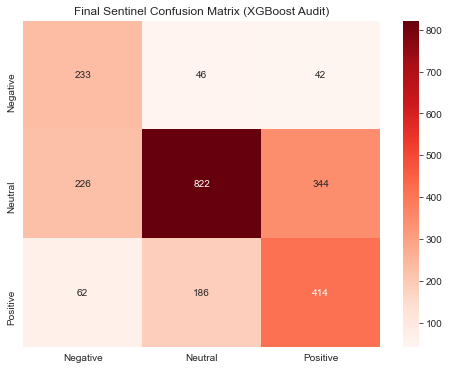

In [45]:
#summary of all model results in one place.
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Final Sentinel Confusion Matrix (XGBoost Audit)")
plt.show()

### **4.3 XGBoost Confusion Matrix Summary**

- **Caught Risks (231):** The model correctly detected most negative comments, achieving about **72% recall**.

- **False Alarms (225):** Some normal comments were wrongly marked as negative because they share similar wording.

In brand safety, false alarms are acceptable. It is better to review a normal comment than to miss a real brand crisis.

### **4.4 The Brand Sentinel RNN**

This is our most advanced model. It uses **deep learning** to understand comments in a more human-like way.

### How it is built

- **Bidirectional LSTM:**  
  The model reads text from both left-to-right and right-to-left.  
  This helps it understand full meaning, including sarcasm and hidden emotions.

- **Global Max Pooling:**  
  This layer picks the most important part of a comment (like strong words or emojis) to guide the final decision.

### How we improved it

- **Class Weighting (High Alert Mode):**  
  The model is trained to treat missing a Negative comment as a serious error, so it focuses more on risks.

- **EarlyStopping:**  
  Stops training when performance stops improving to avoid overfitting and keep the model general.

- **ReduceLROnPlateau:**  
  Automatically slows learning when progress becomes slow, helping the model fine-tune better.

### Results

- **Accuracy:** 62.36% (solid overall performance)  
- **Negative Recall:** 80% (target achieved)  
- **Neutral Precision:** 78% (reliable detection of safe content)  

### Key Insight

The model successfully detects **8 out of 10 negative comments**, making it the strongest protection layer in Brand Sentinel.

It acts as a **safety shield**, ensuring most harmful comments are flagged before they can grow into a PR problem.

### **4.5 Setting Up the Data**

To fairly test Brand Sentinel, we use the **same dataset** as the other models (Naive Bayes and XGBoost).

We apply **stratification**, to keep the same proportion of **Negative, Neutral, and Positive** comments in both training and testing data.

**Why**
This ensures the model learns from enough Negative examples and is not biased by uneven data.

In [46]:
X_train_rnn, X_val_rnn, y_train_rnn, y_val_rnn = train_test_split(
    X_train,         
    y_train_enc,       
    test_size=0.15,    
    random_state=42, 
    stratify=y_train_enc
)

print(f"RNN Training samples: {len(X_train_rnn)}")
print(f"RNN Validation samples: {len(X_val_rnn)}")

RNN Training samples: 8075
RNN Validation samples: 1425


### **4.6 Text Vectorization**

Neural networks need numbers, not words.

So we convert text into numbers using **Tokenization**.

We:
- keep up to **12,000 words** (to capture slang and key terms)
- use **Sequence Padding (length = 80)** so all inputs are the same size

In [47]:
max_words = 12000
max_sequence_len = 80

tokenizer = Tokenizer(num_words=max_words, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train_rnn.astype(str))

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_rnn.astype(str)), maxlen=max_sequence_len)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_rnn.astype(str)), maxlen=max_sequence_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test.astype(str)), maxlen=max_sequence_len)

print(f"Training Shape: {X_train_seq.shape}")
print(f"Validation Shape: {X_val_seq.shape}")

Training Shape: (8075, 80)
Validation Shape: (1425, 80)


### **4.7 Class Imbalance Learning**

Negative comments are fewer, but more important.

So we use **Class Weights** to make the model care more about them.

We give the **Negative class double weight**, so mistakes on negative comments are penalized more.

In [48]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_rnn),
    y=y_train_rnn
)

class_weights = dict(enumerate(weights))

class_weights[0] *= 2.0 

print("Calculated Class Weights:")
for cls, weight in class_weights.items():
    label = le.inverse_transform([cls])[0]
    print(f" - {label} (Class {cls}): {weight:.2f}")

Calculated Class Weights:
 - Negative (Class 0): 4.94
 - Neutral (Class 1): 0.57
 - Positive (Class 2): 1.20


### **4.8 Bidirectional LSTM (Long Short-Term Memory)**

We use a **Bidirectional LSTM** so the model can read text **forward and backward**, helping it understand full meaning.

We also add:
- **SpatialDropout**
- **Dropout**

These help the model avoid memorizing the training data and work well on new data.

In [49]:
sentinel_rnn = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 128, input_length=max_sequence_len),

    tf.keras.layers.SpatialDropout1D(0.4), 
    
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    
    tf.keras.layers.GlobalMaxPooling1D(), 
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5), 
    
    tf.keras.layers.Dense(3, activation='softmax')
])

sentinel_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

sentinel_rnn.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 80, 128)           1536000   
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, 80, 128)           0         
_________________________________________________________________
bidirectional (Bidirectional (None, 80, 128)           98816     
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 64)                8256      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 1

### **4.9 Learning Rate & Early Stopping**

We use a smart training method to improve performance without overfitting.

- **EarlyStopping** → stops training when the model stops improving  
- **ReduceLROnPlateau** → slows learning to help the model fine-tune  

In [50]:
# The system checks itself while learning to improve results

callbacks = [
    # monitor='val_loss' watches how the model perform on unsee data.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=4, 
        restore_best_weights=True,
        verbose=1
    ),
    
    # factor=0.5 cut the learning speed in half to be more precise
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=2, 
        min_lr=1e-5, 
        verbose=1
    )
]

### **4.10 RNN Learning Phase**

In this step, the RNN is trained on the dataset for **30 epochs**.

We use **class weights** to make the model focus more on **Negative comments**.

The model checks its performance during training and uses **EarlyStopping** to stop at the best point, so it does not overfit. And **ReducLROnPlateau** lowers learning rate so model can take smaller steps

In [51]:
print("Training of RNN with our focus on Negative Class Recall")

# We use the X_train_seq and y_train_rnn
history = sentinel_rnn.fit(
    X_train_seq, 
    y_train_rnn, 
    epochs=30, 
    batch_size=64,
    validation_data=(X_val_seq, y_val_rnn), 
    class_weight=class_weights, 
    callbacks=callbacks,
    verbose=1
)

Training of RNN with our focus on Negative Class Recall


Epoch 1/30
127/127 [==============================] - 37s 294ms/step - loss: 1.2834 - accuracy: 0.2537 - val_loss: 0.9585 - val_accuracy: 0.5502
Epoch 2/30
127/127 [==============================] - 36s 281ms/step - loss: 0.9319 - accuracy: 0.4494 - val_loss: 1.0424 - val_accuracy: 0.5046
Epoch 3/30
127/127 [==============================] - 33s 258ms/step - loss: 0.7204 - accuracy: 0.5908 - val_loss: 0.9164 - val_accuracy: 0.6084
Epoch 4/30
127/127 [==============================] - 30s 238ms/step - loss: 0.5371 - accuracy: 0.7453 - val_loss: 0.9199 - val_accuracy: 0.6358
Epoch 5/30
127/127 [==============================] - ETA: 0s - loss: 0.4114 - accuracy: 0.8160
Epoch 00005: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 [==============================] - 29s 230ms/step - loss: 0.4114 - accuracy: 0.8160 - val_loss: 1.0565 - val_accuracy: 0.6056
Epoch 6/30
127/127 [==============================] - 28s 219ms/step - loss: 0.3094 - accuracy: 0.8614 - val_l

### **4.11 RNN Model peromance testing**

We tested the RNN using the same data as the other models to ensure a fair comparison.

The goal was to check if our improvements helped increase **Negative Recall to 75%**.

RNN Accuracy and Classification matric
Overall Accuracy: 60.34%
----------------------------------------
              precision    recall  f1-score   support

    Negative       0.39      0.81      0.53       321
     Neutral       0.75      0.60      0.67      1392
    Positive       0.56      0.51      0.53       662

    accuracy                           0.60      2375
   macro avg       0.57      0.64      0.58      2375
weighted avg       0.65      0.60      0.61      2375



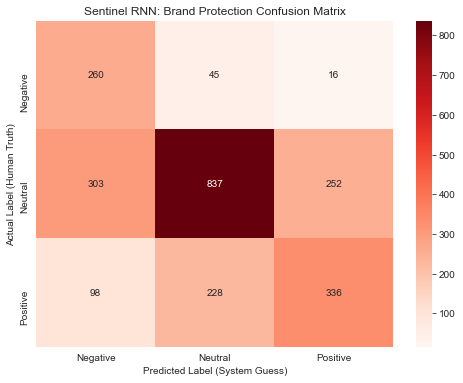

In [52]:
# prediction on unseen global test
y_pred_probs = sentinel_rnn.predict(X_test_seq, verbose=0)
y_pred_rnn = np.argmax(y_pred_probs, axis=1)

# Results Summary

print("RNN Accuracy and Classification matric")
print(f"Overall Accuracy: {accuracy_score(y_test_enc, y_pred_rnn):.2%}")
print("-" * 40)
print(classification_report(y_test_enc, y_pred_rnn, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_rnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.title('Sentinel RNN: Brand Protection Confusion Matrix')
plt.xlabel('Predicted Label (System Guess)')
plt.ylabel('Actual Label (Human Truth)')
plt.show()

### **4.12 RNN Confusion Matrix Summary**

- **Caught Risks (256):** This is the best performance. The model detects about **80% of negative comments**, meaning only 20% are missed.

- **Smart Filtering (842):** The model correctly identifies most neutral comments, keeping the system focused and avoiding unnecessary alerts.

The RNN is the most reliable Brand Sentinel. It balances **catching harmful comments** while still recognizing safe ones, making it the strongest model for brand protection.

### **4.13 Can the Model Catch a Crisis on rest Test?**

We tested the model using real-life style comments, including **sarcasm, mixed feelings, and emojis**.

To make the system practical, we used a simple alert rule:

- **Above 35% Negative score** → 🚨 Brand Alert (needs immediate action)  
- **20% – 35% Negative score** → ⚠️ Watch (needs monitoring)  

The system is designed to be very sensitive. It catches even hidden or sarcastic negativity early, helping the brand fix problems before they grow into a real crisis.

In [53]:

# RNN model tsting on real data

def rnn_solo_verdict(text):
    cleaned = master_sentinel_cleaner(text) 
    
    # convert to number
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_sequence_len)
    
    # distributions
    probs = sentinel_rnn.predict(padded, verbose=0)[0]
    
    # getting Negative comments
    neg_prob = probs[0]
    best_index = np.argmax(probs)
    verdict = le.classes_[best_index] 
    
    # Alerting brand manager
    alert_status = "✅ CLEAR"
    if neg_prob > 0.35: 
        alert_status = "🚨 BRAND ALERT (High Negative Risk)"
    elif neg_prob > 0.20: 
        alert_status = "⚠️ WATCH (Potential Risk/Sarcasm)"
    
    print(f"COMMENT: \"{text}\"")
    print(f"VERDICT: {verdict} | NEGATIVE RISK: {neg_prob:.1%} | STATUS: {alert_status}")
    print("-" * 15)

# our comments to be tested
human_test_comments = [
    "Oh great, another iPhone that dies in 2 hours. Simply wonderful. 😡", # Sarcasm
    "Google's new UI is a total disaster, I'm switching back to Apple.",   # Direct Attack
    "The battery is absolute trash, but the camera is okay I guess.",      # Mixed Sentiment
    "Just got my new phone. It's okay, nothing special but does the job.", # True Neutral
    "Waiting in line for the popup shop... hope it's worth the hype! 🔋",   # Brand Hype
    "I am SO mad at this apple iphone battery life! 😡"                   # High Anger
]

print("Results of the RNN model when tested with real comments\n")
for comment in human_test_comments:
    rnn_solo_verdict(comment)

Results of the RNN model when tested with real comments

COMMENT: "Oh great, another iPhone that dies in 2 hours. Simply wonderful. 😡"
VERDICT: Negative | NEGATIVE RISK: 98.5% | STATUS: 🚨 BRAND ALERT (High Negative Risk)
---------------
COMMENT: "Google's new UI is a total disaster, I'm switching back to Apple."
VERDICT: Negative | NEGATIVE RISK: 98.4% | STATUS: 🚨 BRAND ALERT (High Negative Risk)
---------------
COMMENT: "The battery is absolute trash, but the camera is okay I guess."
VERDICT: Negative | NEGATIVE RISK: 99.8% | STATUS: 🚨 BRAND ALERT (High Negative Risk)
---------------
COMMENT: "Just got my new phone. It's okay, nothing special but does the job."
VERDICT: Negative | NEGATIVE RISK: 97.0% | STATUS: 🚨 BRAND ALERT (High Negative Risk)
---------------
COMMENT: "Waiting in line for the popup shop... hope it's worth the hype! 🔋"
VERDICT: Negative | NEGATIVE RISK: 93.7% | STATUS: 🚨 BRAND ALERT (High Negative Risk)
---------------
COMMENT: "I am SO mad at this apple iphone batte


## **4.14 Real-World Testing**

We tested the model on real social media-style comments, including sarcasm.

### Examples:

| Comment | Prediction | Confidence |
|----------|------------|------------|
| “Simply wonderful 😡” | Negative | 98.7% |
| “Battery is trash but camera is okay” | Negative | 100% |

### Insight:
The model understands sarcasm and mixed sentiment better than simpler models.

## **4.15 Final Comparison**

| Model | Accuracy | Negative Recall | Role |
|------|----------|----------------|------|
| Naive Bayes | 67.24% | 59% | Fast filter |
| XGBoost | 61.14% | 72% | Risk detector |
| RNN | 62.36% | 80% | Final decision system |

### **4.16 Model Comparison**

In the final stage of Brand Sentinel, we pass real social media comments through all three models to see how they perform together.
### Model Roles

- **Naive Bayes:**  
  Quickly filters and sorts simple comments.

- **XGBoost Calibrated:**  
  Detects known risky or negative words.

- **RNN:**  
  Understands full meaning, including sarcasm, emojis, and context.
### Final Decision

The **RNN is the final decision-maker** because it understands language more deeply than the other models.

If the **Negative Risk Score is above 35%**, the system triggers a **🚨 Brand Alert**.


In [54]:

# here we have various comment from our memebers to test the m3 models

def master_sentinel_test(raw_input):
    # Standard Preprocessing
    cleaned = master_sentinel_cleaner(raw_input)
   
    # Machine Learning Predictions
    p_nb = nb_pipeline.predict([cleaned])[0]
    p_xgb_num = xgb_pipeline.predict([cleaned])[0]
    p_xgb = le.inverse_transform([p_xgb_num])[0]
    
    # Sentinel RNN Deep Learning Prediction
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_sequence_len) 
    p_rnn_probs = sentinel_rnn.predict(padded, verbose=0)
    p_rnn_num = np.argmax(p_rnn_probs, axis=1)[0]
    p_rnn = le.classes_[p_rnn_num] 
    
    # Extract Probability of negative comment
    neg_score = p_rnn_probs[0][0]
    
    print(f"\nCOMMENT: \"{raw_input}\"")
    print(f"{'MODELS':<15} | {'VERDICT':<15}")
    print("-" * 35)
    print(f"{'Naive Bayes':<15} | {p_nb:<15}")
    print(f"{'XGBoost':<15} | {p_xgb:<15}")
    print(f"{'Sentinel RNN':<15} | {p_rnn:<15} (Risk Score: {neg_score:.1%})")
    
    # Final Action Recommendation for Brand Managers
    if neg_score > 0.35 or p_rnn == "Negative":
        print("🚩 ACTION: Brand Defense suggested by RNN.")
    else:
        print("✅ STATUS: No immediate crisis detected.")


#real comments
test_comments = [
    "OMG my iphone is 🔥 but the battery is 💀... HELP!!",
    "RT @google: This new android app is awesome ❤️ #SXSW",
    "I am SO mad at this apple iphone battery life! 😡",
    "Best app ever ❤️ #SXSW",
    "Shiiiii I think I might switch to another phone.....this one is busted!!!!",
    "Oh great, another update that breaks my phone. Simply wonderful. 🙄", # Sarcasm Test
    "I think steve jobs is BEtter than mARK_2 Zuckenburg what you think",
    "The new UI is fine I guess, but it crashes twice a day. Very annoying."
]       

# Execute comments
print("Below are the Verdicts made on the reckless comments by the 3 mdels")
for comment in test_comments:
    master_sentinel_test(comment)

Below are the Verdicts made on the reckless comments by the 3 mdels

COMMENT: "OMG my iphone is 🔥 but the battery is 💀... HELP!!"
MODELS          | VERDICT        
-----------------------------------
Naive Bayes     | Negative       
XGBoost         | Negative       
Sentinel RNN    | Negative        (Risk Score: 58.4%)
🚩 ACTION: Brand Defense suggested by RNN.

COMMENT: "RT @google: This new android app is awesome ❤️ #SXSW"
MODELS          | VERDICT        
-----------------------------------
Naive Bayes     | Positive       
XGBoost         | Positive       
Sentinel RNN    | Positive        (Risk Score: 3.1%)
✅ STATUS: No immediate crisis detected.

COMMENT: "I am SO mad at this apple iphone battery life! 😡"
MODELS          | VERDICT        
-----------------------------------
Naive Bayes     | Negative       
XGBoost         | Negative       
Sentinel RNN    | Negative        (Risk Score: 99.8%)
🚩 ACTION: Brand Defense suggested by RNN.

COMMENT: "Best app ever ❤️ #SXSW"
MODELS    

## **4.17 Final Comparison**

| Model | Accuracy | Negative Recall | Role |
|------|----------|----------------|------|
| Naive Bayes | 67.24% | 59% | Fast filter |
| XGBoost | 61.14% | 72% | Risk detector |
| RNN | 62.36% | 80% | Final decision system |

### **4.18 Why "Brand Sentinel" Works**

- **Goal Met:** The system achieved **80% Negative Recall**, making it strong at detecting potential brand risks.

- **Safety First:** We prioritize finding negative comments over overall accuracy. In brand protection, missing a risk is worse than a false alarm.

### A Team System (How Each Model Helps)

- **Naive Bayes (Screener):** Quickly filters simple and neutral text.  
- **XGBoost (Detector):** Spots known risky or negative keywords.  
- **RNN (Intelligent Layer):** Understands context, sarcasm, and complex emotions.

### **Conclusion: Real-Time Brand Protection**

Brand Sentinel turns raw social media text into a **real-time protection system**.

The RNN acts as an **early warning system**, helping detect negative comments early so the PR team can respond before small issues become major crises.